# Audio Analysis Preview

This notebook runs the same librosa-based analysis as the backend, then builds a deterministic cut plan for the example song.

It overlays beat alignment, section boundaries, RMS energy, lyric cues from `test_data/last_align_response.json`, and the selected visual segment boundaries for a chosen part-count range.

In [1]:
from pathlib import Path
import json
import sys

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
BACKEND_DIR = PROJECT_ROOT / 'backend'
if str(BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(BACKEND_DIR))

from audio_analysis import HOP_LENGTH, analyze_audio_structure

In [2]:
def moving_average(values: np.ndarray, width: int) -> np.ndarray:
    if width <= 1:
        return values
    kernel = np.ones(width, dtype=float) / width
    return np.convolve(values, kernel, mode='same')


def local_peak_indices(values: np.ndarray, min_distance: int = 4, min_percentile: float = 75.0) -> np.ndarray:
    if values.size < 3:
        return np.array([], dtype=int)

    threshold = np.percentile(values, min_percentile)
    peaks: list[int] = []

    for idx in range(1, len(values) - 1):
        if values[idx] < threshold:
            continue
        if values[idx] >= values[idx - 1] and values[idx] > values[idx + 1]:
            if peaks and idx - peaks[-1] < min_distance:
                if values[idx] > values[peaks[-1]]:
                    peaks[-1] = idx
                continue
            peaks.append(idx)

    return np.array(peaks, dtype=int)


def snap_to_nearest(value: float, anchors: np.ndarray, max_distance: float = 0.35) -> float:
    if anchors.size == 0:
        return round(float(value), 3)

    idx = int(np.argmin(np.abs(anchors - value)))
    snapped = float(anchors[idx])
    if abs(snapped - value) <= max_distance:
        return round(snapped, 3)
    return round(float(value), 3)


def choose_target_parts(
    part_range: tuple[int, int],
    duration: float,
    bpm: float,
    cue_count: int,
    section_count: int,
    peak_count: int,
    max_supported_parts: int,
) -> int:
    low, high = part_range

    density = 0.0
    density += min(1.0, max(0.0, (bpm - 80.0) / 80.0)) * 0.35
    density += min(1.0, cue_count / max(1.0, duration / 5.0)) * 0.30
    density += min(1.0, section_count / max(1.0, duration / 10.0)) * 0.20
    density += min(1.0, peak_count / max(1.0, duration / 3.0)) * 0.15

    target = int(round(low + (high - low) * min(1.0, density)))
    return max(low, min(target, max_supported_parts))


def build_cut_plan(
    analysis: dict[str, object],
    cues: list[dict[str, object]],
    rms_times: np.ndarray,
    rms_values: np.ndarray,
    part_range: tuple[int, int],
) -> tuple[list[float], list[dict[str, object]], list[dict[str, object]], np.ndarray]:
    duration = float(analysis['duration'])
    bpm = float(analysis['bpm'])
    beat_grid = np.array(analysis['beatGrid'], dtype=float)
    section_boundaries = np.array(analysis['sectionBoundaries'], dtype=float)

    peak_idx = local_peak_indices(rms_values, min_distance=5, min_percentile=70.0)
    energy_peaks = np.array(
        [snap_to_nearest(float(rms_times[idx]), beat_grid, 0.4) for idx in peak_idx],
        dtype=float,
    )

    if rms_values.max() > rms_values.min():
        rms_norm = (rms_values - rms_values.min()) / (rms_values.max() - rms_values.min())
    else:
        rms_norm = np.zeros_like(rms_values)

    candidates: dict[float, dict[str, object]] = {}

    def add_candidate(time_sec: float, base_score: float, reason: str) -> None:
        time_sec = float(np.clip(time_sec, 0.0, duration))
        if time_sec <= 0.5 or time_sec >= duration - 0.5:
            return

        snapped = snap_to_nearest(time_sec, beat_grid, 0.35)
        item = candidates.setdefault(
            snapped,
            {
                'time': snapped,
                'score': 0.0,
                'reasons': [],
            },
        )
        item['score'] = max(float(item['score']), base_score)
        if reason not in item['reasons']:
            item['reasons'].append(reason)

    for boundary in section_boundaries[1:-1]:
        add_candidate(float(boundary), 1.0, 'section-change')

    for cue in cues:
        cue_start = float(cue['start'])
        cue_end = cue_start + float(cue['duration'])
        add_candidate(cue_start, 0.72, 'lyric-start')
        add_candidate(cue_end, 0.82, 'lyric-end')

    for idx in range(len(cues) - 1):
        prev_end = float(cues[idx]['start']) + float(cues[idx]['duration'])
        next_start = float(cues[idx + 1]['start'])
        pause = next_start - prev_end
        if pause >= 0.35:
            add_candidate((prev_end + next_start) / 2.0, 0.94, f'lyric-pause {pause:.2f}s')

    for idx in peak_idx:
        score = 0.55 + 0.35 * float(rms_norm[idx])
        add_candidate(float(rms_times[idx]), score, 'energy-peak')

    ranked = sorted(
        candidates.values(),
        key=lambda item: (-float(item['score']), float(item['time'])),
    )

    max_supported_parts = max(2, int(duration // 1.8))
    target_parts = choose_target_parts(
        part_range=part_range,
        duration=duration,
        bpm=bpm,
        cue_count=len(cues),
        section_count=max(0, len(section_boundaries) - 1),
        peak_count=len(peak_idx),
        max_supported_parts=max_supported_parts,
    )

    ideal_gap = duration / target_parts
    min_gap = max(1.6, ideal_gap * 0.55)
    max_gap = ideal_gap * 1.70

    selected = [0.0, duration]
    selected_meta: dict[float, dict[str, object]] = {}

    def gap_ok(time_sec: float) -> bool:
        boundaries = sorted(selected + [time_sec])
        gaps = np.diff(boundaries)
        return bool(np.all(gaps >= min_gap - 1e-9))

    for item in ranked:
        if len(selected) >= target_parts + 1:
            break
        time_sec = float(item['time'])
        if gap_ok(time_sec):
            selected.append(time_sec)
            selected_meta[time_sec] = item

    while len(selected) < target_parts + 1:
        boundaries = sorted(selected)
        gaps = [(boundaries[i], boundaries[i + 1]) for i in range(len(boundaries) - 1)]
        start, end = max(gaps, key=lambda pair: pair[1] - pair[0])
        midpoint = snap_to_nearest((start + end) / 2.0, beat_grid, 0.5)
        if midpoint <= start + min_gap / 2.0 or midpoint >= end - min_gap / 2.0:
            break
        if midpoint not in selected:
            selected.append(midpoint)
            selected_meta[midpoint] = {
                'time': midpoint,
                'score': 0.40,
                'reasons': ['spacing-fill'],
            }

    selected = sorted(set(round(float(time_sec), 3) for time_sec in selected))

    changed = True
    while changed:
        changed = False
        for start, end in zip(selected[:-1], selected[1:]):
            if end - start <= max_gap:
                continue

            interval_candidates = [
                item
                for item in ranked
                if start + min_gap / 2.0 < float(item['time']) < end - min_gap / 2.0
            ]

            if interval_candidates:
                choice = float(interval_candidates[0]['time'])
            else:
                choice = snap_to_nearest((start + end) / 2.0, beat_grid, 0.5)

            if choice not in selected and start + min_gap / 2.0 < choice < end - min_gap / 2.0:
                selected.append(choice)
                if choice not in selected_meta:
                    selected_meta[choice] = {
                        'time': choice,
                        'score': 0.45,
                        'reasons': ['gap-split'],
                    }
                selected = sorted(selected)
                changed = True
                break

    segments: list[dict[str, object]] = []
    for segment_number, (start, end) in enumerate(zip(selected[:-1], selected[1:]), start=1):
        reason_tokens: list[str] = []
        for boundary in (start, end):
            meta = selected_meta.get(boundary)
            if meta:
                reason_tokens.extend(str(reason) for reason in meta['reasons'])

        cue_snippets: list[str] = []
        for cue in cues:
            cue_start = float(cue['start'])
            cue_end = cue_start + float(cue['duration'])
            overlap = max(0.0, min(end, cue_end) - max(start, cue_start))
            if overlap >= 0.35:
                cue_snippets.append(str(cue['text']))

        label = ' | '.join(cue_snippets[:2]).strip()
        if len(label) > 80:
            label = label[:77] + '...'

        segments.append(
            {
                'segment': segment_number,
                'start': round(start, 3),
                'end': round(end, 3),
                'duration': round(end - start, 3),
                'drivers': ', '.join(dict.fromkeys(reason_tokens)) if reason_tokens else 'start/end',
                'lyric_excerpt': label,
            }
        )

    return selected, ranked, segments, energy_peaks


AUDIO_PATH = PROJECT_ROOT / 'test_data' / 'clip.mp3'
ALIGNMENT_PATH = PROJECT_ROOT / 'test_data' / 'last_align_response.json'

PART_RANGE = (6, 10)
MIN_SECTION_DURATION = 8.0
MAX_SECTIONS = 10

analysis = analyze_audio_structure(
    str(AUDIO_PATH),
    min_section_duration=MIN_SECTION_DURATION,
    max_sections=MAX_SECTIONS,
)

audio, sample_rate = librosa.load(AUDIO_PATH, sr=None, mono=True)

onset_times = np.array([point['time'] for point in analysis['onsetStrength']], dtype=float)
onset_values = np.array([point['value'] for point in analysis['onsetStrength']], dtype=float)
beat_grid = np.array(analysis['beatGrid'], dtype=float)
section_boundaries = np.array(analysis['sectionBoundaries'], dtype=float)

rms_values = librosa.feature.rms(y=audio, hop_length=HOP_LENGTH)[0].astype(float)
rms_values = moving_average(rms_values, 9)
rms_times = librosa.times_like(rms_values, sr=sample_rate, hop_length=HOP_LENGTH)

alignment = json.loads(ALIGNMENT_PATH.read_text(encoding='utf-8')) if ALIGNMENT_PATH.exists() else {'cues': []}
cues = alignment.get('cues', [])

cut_boundaries, ranked_candidates, segments, energy_peaks = build_cut_plan(
    analysis=analysis,
    cues=cues,
    rms_times=rms_times,
    rms_values=rms_values,
    part_range=PART_RANGE,
)

segments_df = pd.DataFrame(segments)
candidates_df = pd.DataFrame(
    [
        {
            'time': round(float(item['time']), 3),
            'score': round(float(item['score']), 3),
            'reasons': ', '.join(str(reason) for reason in item['reasons']),
        }
        for item in ranked_candidates
    ]
)

print(f'Audio: {AUDIO_PATH}')
print(f"Duration: {analysis['duration']} s")
print(f"Sample rate: {analysis['sampleRate']} Hz")
print(f"Estimated BPM: {analysis['bpm']}")
print(f'Lyric cues loaded: {len(cues)}')
print(f'Requested part range: {PART_RANGE[0]}-{PART_RANGE[1]}')
print(f'Chosen visual parts: {len(cut_boundaries) - 1}')

display(segments_df)
display(candidates_df.head(15))

c:\Users\miskibin\music-video\backend\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Audio: C:\Users\miskibin\music-video\test_data\clip.mp3
Duration: 148.92 s
Sample rate: 48000 Hz
Estimated BPM: 187.5
Lyric cues loaded: 2
Requested part range: 6-10
Chosen visual parts: 10


,segment,start,end,duration,drivers,lyric_excerpt
0,1,0.000,26.635,26.635,gap-split,O te prawa odebrane o planetę i nadzieję walczyć
1,2,26.635,33.536,6.901,"gap-split, section-change",
2,3,33.536,57.419,23.883,section-change,"Każdy z nas i każda z nas, każde ono ich i je ..."
3,4,57.419,73.045,15.626,"section-change, energy-peak",
4,5,73.045,99.360,26.315,"energy-peak, section-change",
5,6,99.360,108.544,9.184,"section-change, energy-peak",
6,7,108.544,120.597,12.053,energy-peak,
7,8,120.597,130.165,9.568,"energy-peak, section-change",
8,9,130.165,139.659,9.494,"section-change, energy-peak",
9,10,139.659,148.920,9.261,energy-peak,


,time,score,reasons
0,3.979,1.000,"section-change, energy-peak"
1,33.536,1.000,section-change
2,36.469,1.000,section-change
3,57.419,1.000,section-change
4,99.360,1.000,section-change
5,101.547,1.000,"section-change, energy-peak"
6,130.165,1.000,"section-change, energy-peak"
7,133.003,1.000,"section-change, energy-peak"
8,135.541,1.000,section-change
9,26.635,0.940,lyric-pause 22.70s


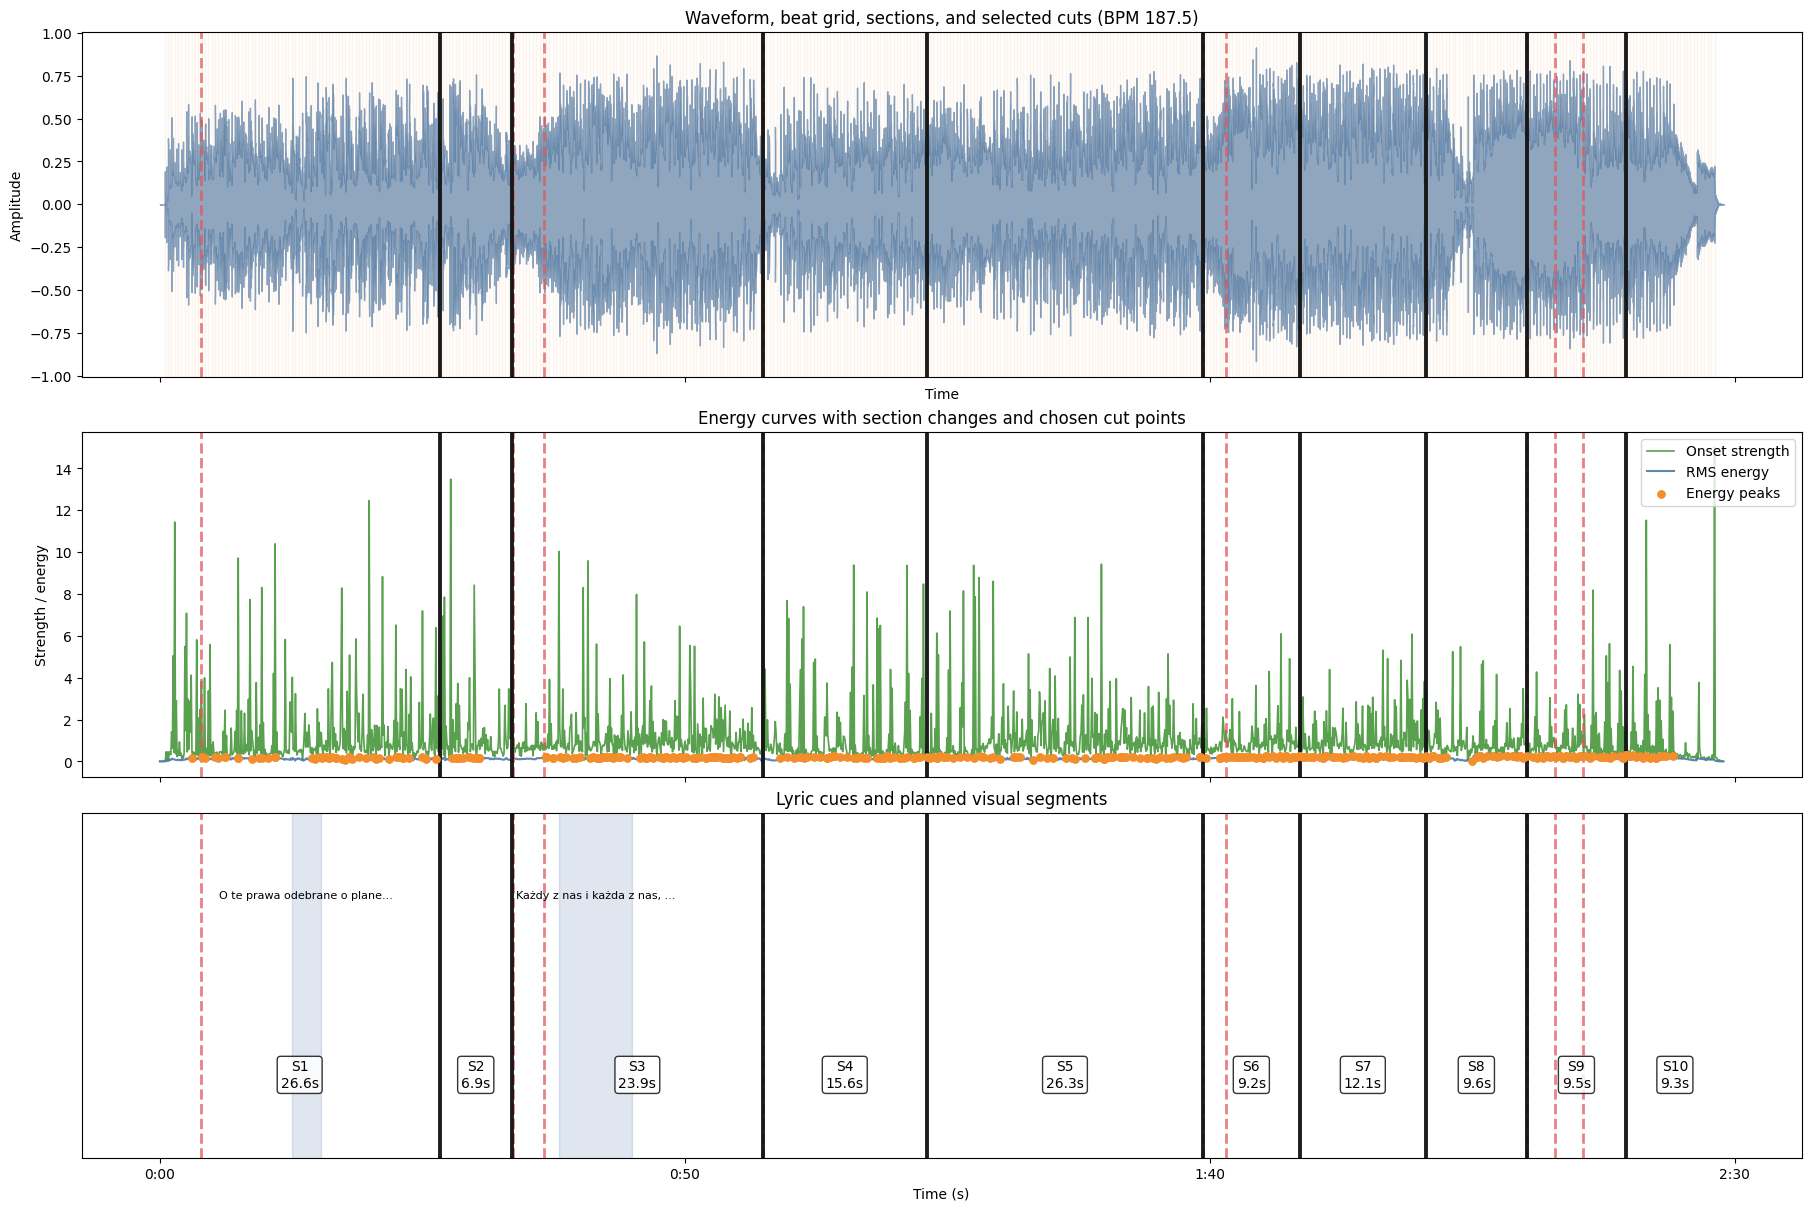

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True, constrained_layout=True)

librosa.display.waveshow(audio, sr=sample_rate, ax=axes[0], alpha=0.65, color='#4e79a7')
axes[0].set_title(f"Waveform, beat grid, sections, and selected cuts (BPM {analysis['bpm']})")
axes[0].set_ylabel('Amplitude')

for beat_time in beat_grid:
    axes[0].axvline(beat_time, color='#f28e2b', alpha=0.10, linewidth=1)

for boundary_time in section_boundaries[1:-1]:
    axes[0].axvline(boundary_time, color='#e15759', linestyle='--', linewidth=2, alpha=0.75)

for cut_time in cut_boundaries[1:-1]:
    axes[0].axvline(cut_time, color='#111111', linewidth=2.8, alpha=0.95)

axes[1].plot(onset_times, onset_values, color='#59a14f', linewidth=1.2, label='Onset strength')
axes[1].plot(rms_times, rms_values, color='#4e79a7', linewidth=1.5, alpha=0.9, label='RMS energy')
if energy_peaks.size:
    peak_values = np.interp(energy_peaks, rms_times, rms_values)
    axes[1].scatter(energy_peaks, peak_values, color='#f28e2b', s=28, zorder=3, label='Energy peaks')

for boundary_time in section_boundaries[1:-1]:
    axes[1].axvline(boundary_time, color='#e15759', linestyle='--', linewidth=2, alpha=0.75)

for cut_time in cut_boundaries[1:-1]:
    axes[1].axvline(cut_time, color='#111111', linewidth=2.8, alpha=0.95)

axes[1].set_title('Energy curves with section changes and chosen cut points')
axes[1].set_ylabel('Strength / energy')
axes[1].legend(loc='upper right')

axes[2].set_title('Lyric cues and planned visual segments')
axes[2].set_ylim(0, 1)
axes[2].set_yticks([])
axes[2].set_xlabel('Time (s)')

for cue in cues:
    cue_start = float(cue['start'])
    cue_end = cue_start + float(cue['duration'])
    axes[2].axvspan(cue_start, cue_end, color='#4e79a7', alpha=0.18)

    label = str(cue['text'])
    if len(label) > 30:
        label = label[:27] + '...'
    axes[2].text(
        (cue_start + cue_end) / 2.0,
        0.76,
        label,
        ha='center',
        va='center',
        fontsize=8,
        clip_on=True,
    )

for boundary_time in section_boundaries[1:-1]:
    axes[2].axvline(boundary_time, color='#e15759', linestyle='--', linewidth=2, alpha=0.75)

for cut_time in cut_boundaries[1:-1]:
    axes[2].axvline(cut_time, color='#111111', linewidth=2.8, alpha=0.95)

for row in segments:
    center = (float(row['start']) + float(row['end'])) / 2.0
    axes[2].text(
        center,
        0.24,
        f"S{int(row['segment'])}\n{float(row['duration']):.1f}s",
        ha='center',
        va='center',
        fontsize=10,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='#111111', alpha=0.85),
    )

plt.show()